In [15]:
# Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score             

In [16]:
# Dataset Load 
data = fetch_california_housing(as_frame=True)

# DataFrame
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print("Dataset Shape:", df.shape)
print("\n 5 Rows:")
df.head()

Dataset Shape: (20640, 9)

 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
# Data basic info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

=== Basic Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


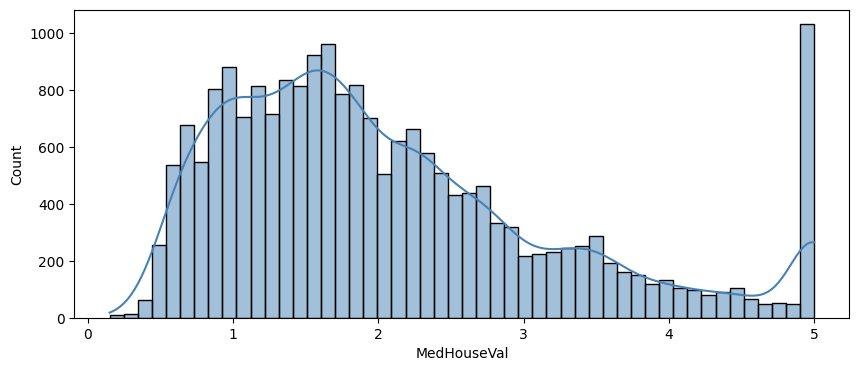

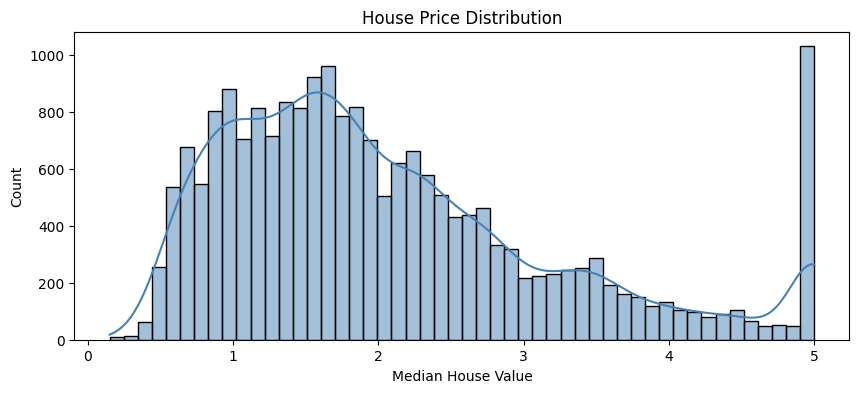

In [18]:
# House Price Distribution

plt.figure(figsize=(10, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.figure(figsize=(10, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.title("House Price Distribution")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

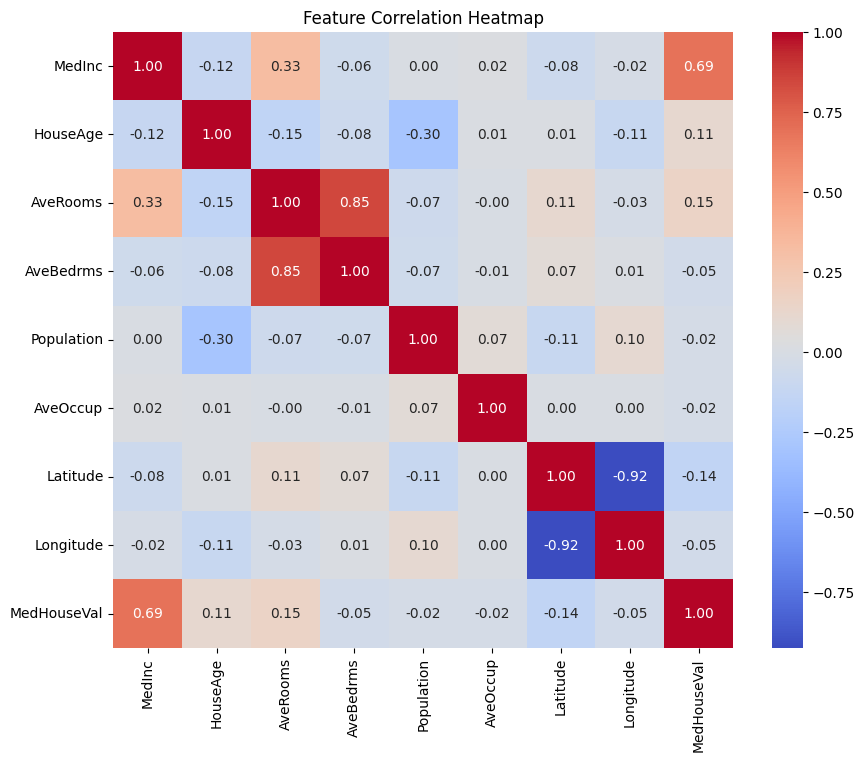

In [19]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

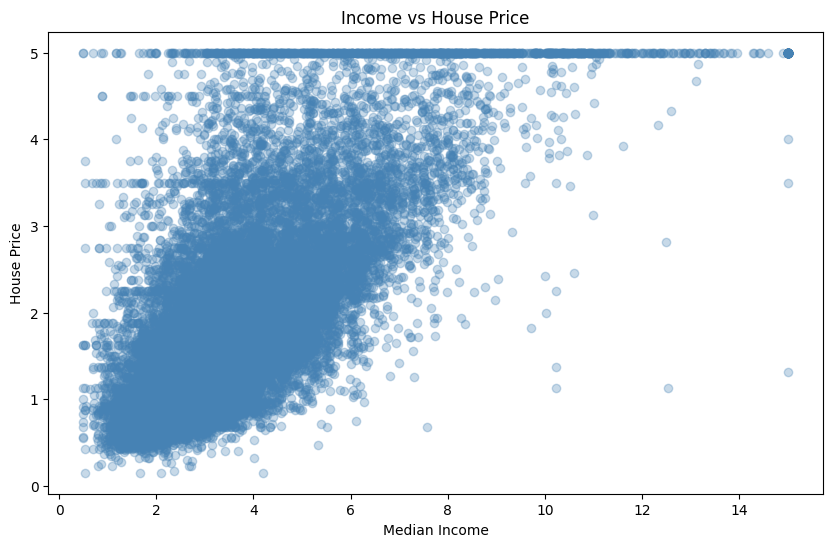

In [20]:
# Income vs House Price Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, color='steelblue')
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs House Price")
plt.show()

In [21]:
# Separate Features and Target
X = df.drop(columns='MedHouseVal')  # all features
y = df['MedHouseVal']               # target variable

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Done!")
print(f"Training rows  : {X_train.shape[0]}")
print(f"Testing rows   : {X_test.shape[0]}")

Data Split Done!
Training rows  : 16512
Testing rows   : 4128


In [22]:
# Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on Test Data
y_pred = model.predict(X_test)

print("Model Training Complete! ✅")
print(f"Coefficients : {model.coef_}")
print(f"Intercept    : {model.intercept_:.3f}")

Model Training Complete! ✅
Coefficients : [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept    : -37.023


In [23]:
# Model Evaluation
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

=== Model Performance ===
MAE  : 0.533
RMSE : 0.746
R²   : 0.576


C:\Users\pawan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


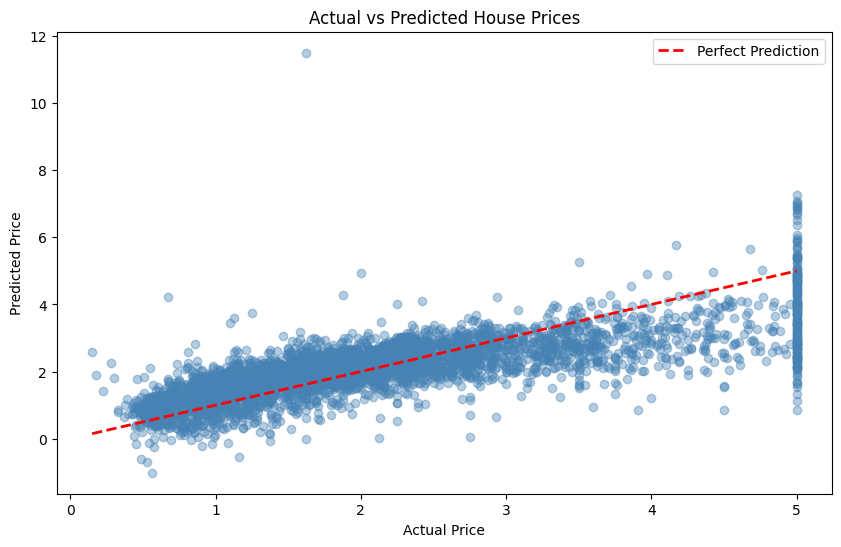

In [24]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Perfect Prediction'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

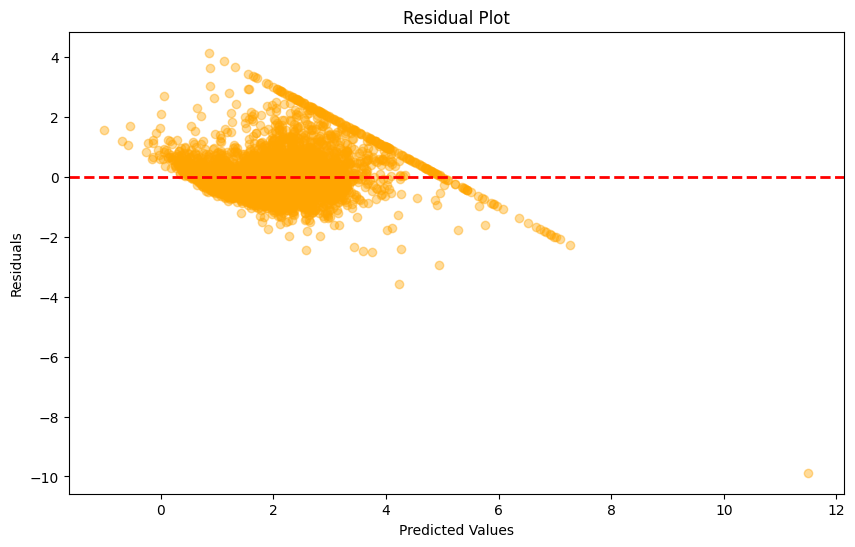

In [25]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.4, color='orange')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [26]:
import pickle

# Save the model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model Saved Successfully! ✅")
print("File: house_price_model.pkl")

Model Saved Successfully! ✅
File: house_price_model.pkl


In [27]:
# Predict on New House Data
new_house = [[8.3252, 41.0, 6.984, 1.024, 322.0, 2.555, 37.88, -122.23]]

prediction = model.predict(new_house)

# Currency Conversion
usd_price = prediction[0] * 100000
inr_price = usd_price * 83.5  # 1 USD = 83.5 INR

print("=== New House Prediction ===")
print(f"Predicted Price (USD) : ${usd_price:,.0f}")
print(f"Predicted Price (INR) : ₹{inr_price:,.0f}")

=== New House Prediction ===
Predicted Price (USD) : $415,211
Predicted Price (INR) : ₹34,670,114


C:\Users\pawan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
# Final Project Summary
print("=" * 45)
print("   CALIFORNIA HOUSE PRICE PREDICTOR")
print("=" * 45)
print(f"\n Dataset Details:")
print(f"   Total Rows     : {df.shape[0]}")
print(f"   Total Features : {df.shape[1]-1}")
print(f"\n Train/Test Split:")
print(f"   Training Rows  : {X_train.shape[0]}")
print(f"   Testing Rows   : {X_test.shape[0]}")
print(f"\n Model Performance:")
print(f"   MAE  : {mae:.3f}")
print(f"   RMSE : {rmse:.3f}")
print(f"   R²   : {r2:.3f}")
print(f"\n Prediction on New House:")
print(f"   USD  : ${usd_price:,.0f}")
print(f"   INR  : ₹{inr_price:,.0f}")
print("\n" + "=" * 45)
print("   Project Complete! ✅")
print("=" * 45)

   CALIFORNIA HOUSE PRICE PREDICTOR

 Dataset Details:
   Total Rows     : 20640
   Total Features : 8

 Train/Test Split:
   Training Rows  : 16512
   Testing Rows   : 4128

 Model Performance:
   MAE  : 0.533
   RMSE : 0.746
   R²   : 0.576

 Prediction on New House:
   USD  : $415,211
   INR  : ₹34,670,114

   Project Complete! ✅
